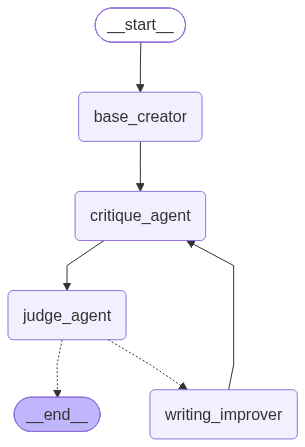


--- base_creator ---
Draft:
The sun sank like a molten coin, spilling amber and rose across the snow-capped peaks, their jagged teeth glistening as if kissed by fire. The air turned brittle, each breath a shard of ice, while the scent of pine and earth mingled with the faint, metallic tang of frost. Shadows stretched like ink across the valley, swallowing the last light as the sky bled into indigo.  

A hush settled, heavy as a tomb. Then—*a crack*. Deep beneath the glacier, a tremor rippled, sending a shiver through the snow. The ground quivered, and from the heart of the mountain, a low, resonant growl rumbled, vibrating in the bones. Snow began to fall, not as flakes, but as a cascade of diamonds, each one catching the last dying light.  

Something stirred. A shape emerged—massive, hulking, its form a mosaic of shadow and bone. Its eyes, twin pools of molten gold, glowed faintly, piercing the dark. The air grew thick, charged with the musk of ancient fur and the whisper of primal 

In [ ]:
from IPython.core.display import Image
from langgraph.constants import START, END
from langgraph.graph import StateGraph
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage
from typing import TypedDict, Annotated, Literal, Optional
from pydantic import SecretStr, BaseModel, Field
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv

load_dotenv()
api_key = os.getenv("LLAMA_API_KEY")
if api_key is None:
    raise ValueError("Missing LLAMA_API_KEY in environment")

llm = ChatOpenAI(
    base_url="http://localhost:8080/v1",
    api_key=SecretStr(api_key),  # llama.cpp server doesn't require an API key by default
    model="qwen3_8b-Q4_K_M",
    temperature=0.7
)

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    critiques: Annotated[list[AnyMessage], operator.add]
    llm_calls: int
    next_step: Optional[Literal["continue", "end"]]

def base_creator(state: MessagesState):
    return {
        "messages": [
            llm.invoke(
                [
                    SystemMessage(
                        content="Write a short scene based on the requirements. Use techniques like varying sentence structures where needed, vivid imagery, 5 senses to convey the scene thoroughly and expressively."
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get('llm_calls', 0) + 1
    }

def critique_agent(state: MessagesState):
    return {
        "critiques": [
            llm.invoke(
                [
                    SystemMessage(
                        content="Act as a ruthless, top-tier editor with zero tolerance for weak prose. Read the provided text and deliver a scathing, high-impact critique that aggressively targets its single worst aspect—whether that is bloated phrasing, clunky syntax, passive voice, or vague imagery. Skip all polite intros and pleasantries; jump straight into dissecting what fails, explaining precisely why it weakens the piece, and showing how to fix it with unrelenting clarity."
                    ),
                    HumanMessage(f"Critique this Draft: {state["messages"][-1]}")
                ]
            )
        ]
    }

class FinalDecision(BaseModel):
    should_end: bool
    reason: str

def agent_node(state: MessagesState) -> dict:
    structured_llm = llm.with_structured_output(FinalDecision)
    res = structured_llm.invoke(
        state["messages"]
    )

    return {
        "next_step": "end" if res.should_end else "continue"
    }

def route_decision(state: MessagesState) -> Literal["writing_improver", END]:
    if state.get("next_step") == "end":
        return END
    return "writing_improver"

def judge_agent(state: MessagesState):
    judge_llm = llm.with_structured_output(FinalDecision)

    last_message = state["messages"][-1]
    last_critique = state["critiques"][-1]

    res = judge_llm.invoke(
        [
            SystemMessage("You are a fair judge. Evaluate this writing with critiques. Based on whether the critique is valid and there is room for improvement, choose whether to continue or not."),
            HumanMessage(f"Draft:\n{last_message}\n\nCritique:{last_critique}"),
        ]
    )

    return {
        "next_step": "end" if res.should_end else "continue"
    }

def writing_improver(state: MessagesState):
    last_message = state["messages"][-1]
    last_critique = state["critiques"][-1]

    return {
        "messages": [
            llm.invoke(
                [
                    SystemMessage("You are a professional fiction writer. Rewrite the draft below addressing the editor's critique.\n"
        "STRICT RULE: Output ONLY the revised prose. Do NOT include explanations, bullet points, "
        "headers, notes, or intros. Return ONLY the story text."),
                    HumanMessage(f"Draft:\n{last_message}\n\nCritique:{last_critique}")
                ]
            )
        ]
    }

agent_builder = StateGraph(MessagesState)
agent_builder.add_node("base_creator", base_creator)
agent_builder.add_node("critique_agent", critique_agent)
agent_builder.add_node("judge_agent", judge_agent)
agent_builder.add_node("writing_improver", writing_improver)

agent_builder.add_edge(START, "base_creator")
agent_builder.add_edge("base_creator", "critique_agent")
agent_builder.add_edge("critique_agent", "judge_agent")
agent_builder.add_conditional_edges(
    "judge_agent",
    route_decision,
    ["writing_improver", END]
)
agent_builder.add_edge("writing_improver", "critique_agent")

agent = agent_builder.compile()
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

messages = [HumanMessage(content="Sun sets across the snowy peaks. As night falls, something deep within the mountain range awakens")]
for chunk in agent.stream({"messages": messages}, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- {node_name} ---")
        if "messages" in node_output:
            print(f"Draft:\n{node_output['messages'][-1].content}")
        if "critiques" in node_output:
            print(f"Critique:\n{node_output['critiques'][-1].content}")
        if "next_step" in node_output:
            print(f"Decision: {node_output['next_step']}")